<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn

# ─── Imports ───
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})
SEED = 42
np.random.seed(SEED)

print("Environment ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
Environment ready.


In [3]:
# ─── Load Dataset ───
df = pd.read_csv("/content/drive/MyDrive/Dataset/breast_cancer_enhanced_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['diagnosis'].value_counts()}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Drop id and prepare target
df = df.drop(columns=['id'])
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # B=0, M=1

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"Features: {X.shape[1]}")
df.head()

Dataset shape: (5500, 17)
Class distribution:
diagnosis
B    3470
M    2030
Name: count, dtype: int64
Missing values: 0
Features: 15


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
0,0,11.829858,21.726166,75.154378,435.022394,0.087089,0.050717,0.015868,0.011641,0.078226,0.000185,0.026075,257.017451,0.187718,0.000036,22.433798
1,0,10.991150,17.103260,71.798929,381.386295,0.089339,0.109498,0.097344,0.035629,0.242470,0.003468,0.080823,187.984489,1.069921,0.000255,24.021839
2,1,21.433519,15.092437,142.753006,1392.399890,0.099557,0.152079,0.193372,0.126922,0.472373,0.024543,0.157458,323.484034,4.144647,0.000139,49.053992
3,0,11.700452,14.872127,74.154481,404.112556,0.101291,0.077563,0.043749,0.028747,0.150059,0.001258,0.050020,174.010599,0.511885,0.000108,23.276145
4,0,13.259377,17.212990,83.621014,521.124238,0.072905,0.043312,0.046983,0.010096,0.100391,0.000474,0.033464,228.233523,0.622960,0.000090,25.647074


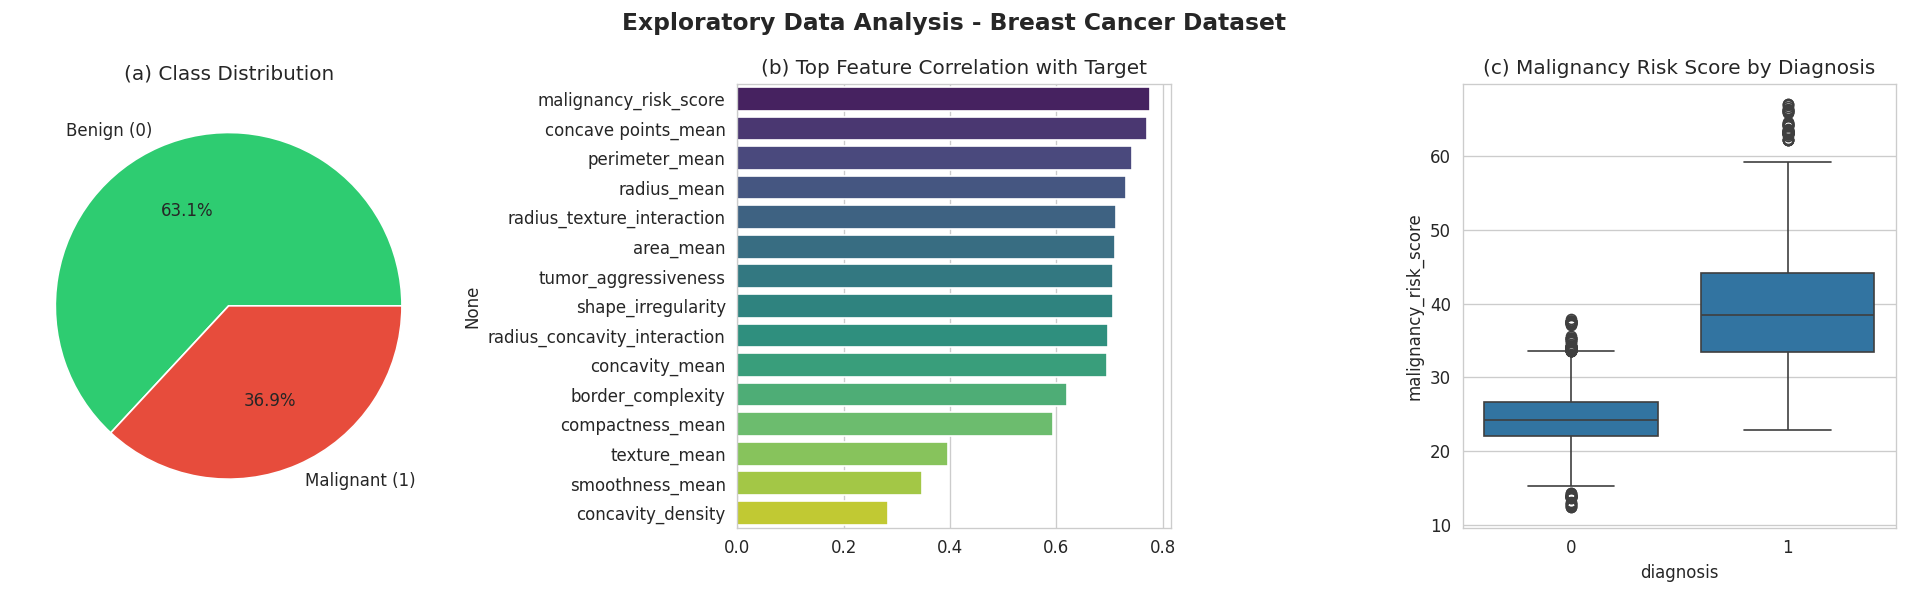

In [4]:
# ─── EDA ───
num_df = X.copy()
num_df['diagnosis'] = y

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class Distribution
lbl = y.value_counts()
axes[0].pie(lbl, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'])
axes[0].set_title("(a) Class Distribution")

# Correlation (top features)
corr = num_df.corr()['diagnosis'].abs().sort_values(ascending=False)
top_corr = corr[1:16]  # top 15 features
sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[1], palette="viridis")
axes[1].set_title("(b) Top Feature Correlation with Target")

# Feature distributions example
sns.boxplot(x='diagnosis', y='malignancy_risk_score', data=num_df, ax=axes[2])
axes[2].set_title("(c) Malignancy Risk Score by Diagnosis")

plt.suptitle("Exploratory Data Analysis - Breast Cancer Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

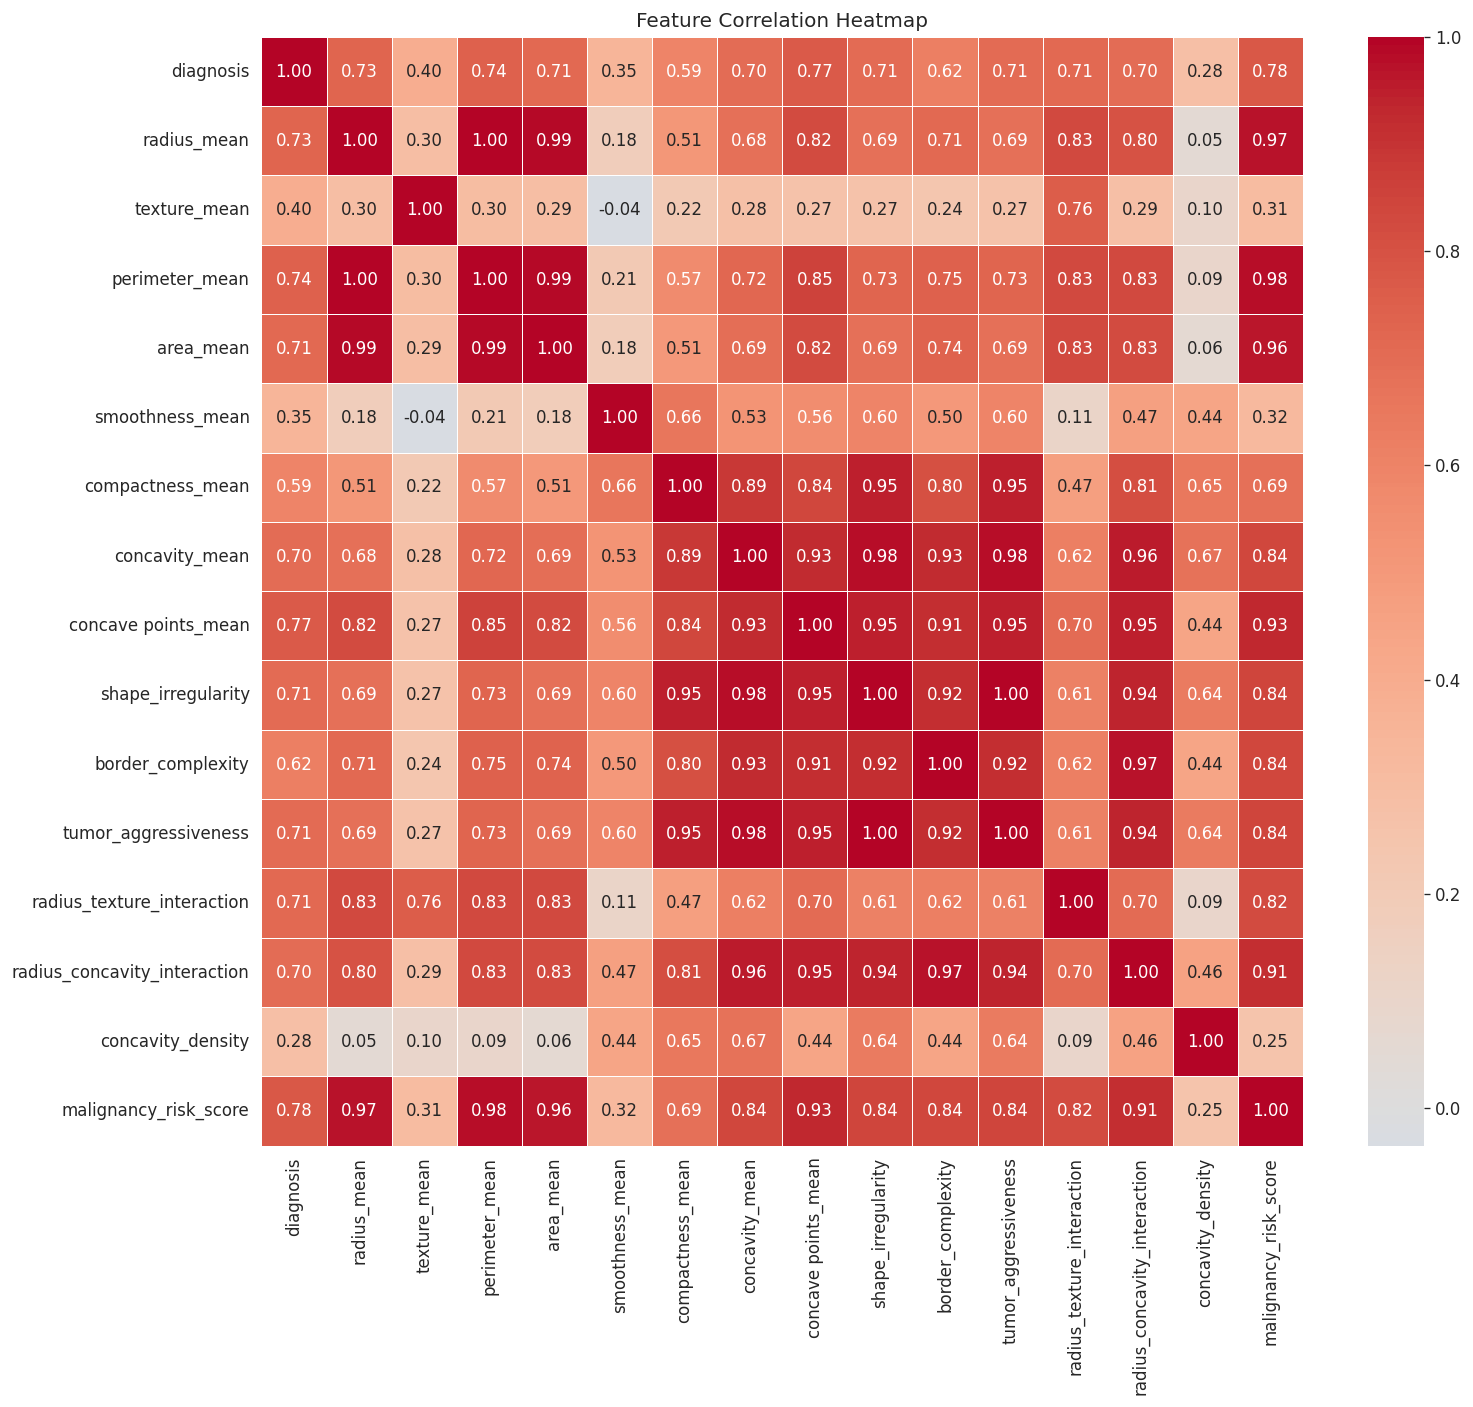

In [5]:
# Correlation Heatmap
plt.figure(figsize=(14, 12))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
# ─── Preprocessing ───
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (4400, 15), Test shape: (1100, 15)


In [7]:
# ====================== MODELS ======================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=10, gamma="scale", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=SEED),
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, verbose=0, random_state=SEED)
}

results = []

print("Training Individual Classifiers...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

# ====================== VOTING ENSEMBLE ======================
print("Training Voting Ensemble (Soft)...\n")
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
y_pred_vot = voting_clf.predict(X_test)
y_prob_vot = voting_clf.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Voting Ensemble (Soft)",
    "Accuracy": accuracy_score(y_test, y_pred_vot),
    "Precision": precision_score(y_test, y_pred_vot),
    "Recall": recall_score(y_test, y_pred_vot),
    "F1-Score": f1_score(y_test, y_pred_vot),
    "AUC-ROC": roc_auc_score(y_test, y_prob_vot)
})

# ====================== FINAL RESULTS ======================
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).round(4)
print("=== FINAL PERFORMANCE COMPARISON (Individual + Ensemble) ===")
print(results_df)

Training Individual Classifiers...

Training Voting Ensemble (Soft)...

=== FINAL PERFORMANCE COMPARISON (Individual + Ensemble) ===
                    Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
6                CatBoost    1.0000     1.0000  1.0000    1.0000   1.0000
7  Voting Ensemble (Soft)    0.9982     1.0000  0.9951    0.9975   1.0000
5                LightGBM    0.9973     1.0000  0.9926    0.9963   1.0000
1                     KNN    0.9964     0.9951  0.9951    0.9951   1.0000
4                 XGBoost    0.9955     0.9975  0.9901    0.9938   1.0000
3           Random Forest    0.9936     0.9950  0.9877    0.9913   0.9999
2                     SVM    0.9755     0.9897  0.9433    0.9660   0.9961
0     Logistic Regression    0.9318     0.9211  0.8916    0.9061   0.9842



CLASSIFICATION REPORTS & CONFUSION MATRICES

🔹 Logistic Regression
--------------------------------------------------
               precision    recall  f1-score   support

   Benign (B)       0.94      0.96      0.95       694
Malignant (M)       0.92      0.89      0.91       406

     accuracy                           0.93      1100
    macro avg       0.93      0.92      0.93      1100
 weighted avg       0.93      0.93      0.93      1100


🔹 KNN
--------------------------------------------------
               precision    recall  f1-score   support

   Benign (B)       1.00      1.00      1.00       694
Malignant (M)       1.00      1.00      1.00       406

     accuracy                           1.00      1100
    macro avg       1.00      1.00      1.00      1100
 weighted avg       1.00      1.00      1.00      1100


🔹 SVM
--------------------------------------------------
               precision    recall  f1-score   support

   Benign (B)       0.97      0.99      0.9

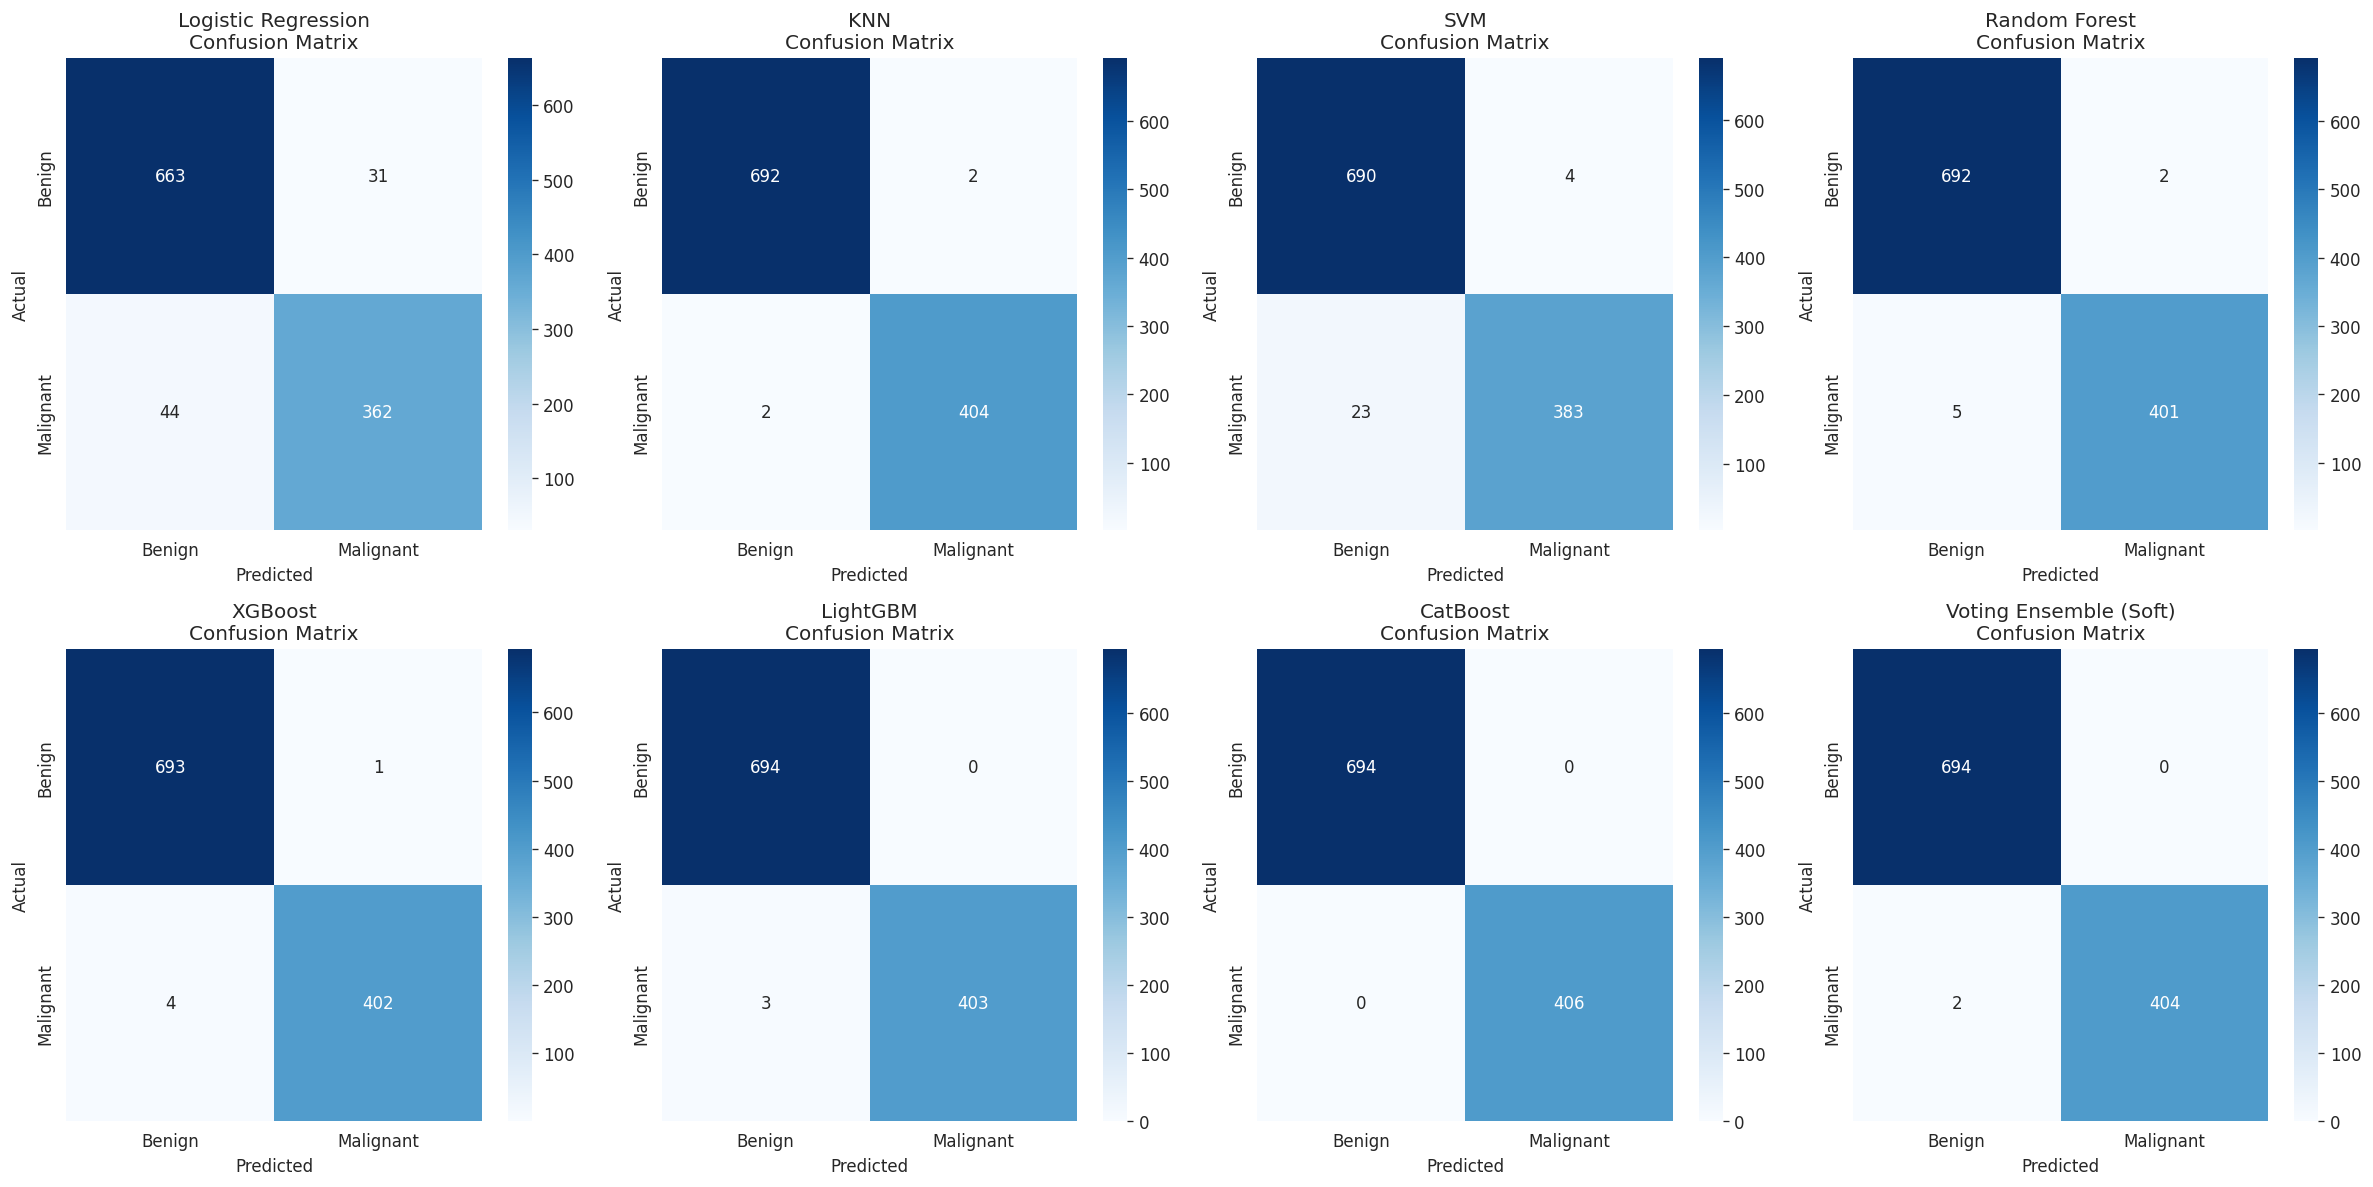

In [8]:
print("\n" + "="*60)
print("CLASSIFICATION REPORTS & CONFUSION MATRICES")
print("="*60)

# Create a figure for confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

model_list = list(models.items()) + [("Voting Ensemble (Soft)", voting_clf)]
cm_list = []

for i, (name, model) in enumerate(model_list):
    y_pred = model.predict(X_test)

    # Classification Report
    print(f"\n🔹 {name}")
    print("-" * 50)
    print(classification_report(y_test, y_pred, target_names=['Benign (B)', 'Malignant (M)']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_list.append((name, cm))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                ax=axes[i])
    axes[i].set_title(f'{name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_grid.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Best Model Detailed Report
best = results_df.iloc[0]
print(f"\n🏆 Best Model: {best['Model']} (Accuracy = {best['Accuracy']:.4f})")
if best['Model'] == "Voting Ensemble (Soft)":
    print(classification_report(y_test, y_pred_vot))
else:
    print(classification_report(y_test, models[best['Model']].predict(X_test)))


🏆 Best Model: CatBoost (Accuracy = 1.0000)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       694
           1       1.00      1.00      1.00       406

    accuracy                           1.00      1100
   macro avg       1.00      1.00      1.00      1100
weighted avg       1.00      1.00      1.00      1100



In [13]:
# After training all models and showing main results_df

best_model_name = results_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")



Best Model: CatBoost


In [14]:
# ====================== 5-FOLD CV ON BEST MODEL ======================
print(f"\n{'='*65}")
print(f"5-FOLD STRATIFIED CROSS VALIDATION - {best_model_name}")
print(f"{'='*65}")

# Safely select the model for CV
if best_model_name == "Voting Ensemble (Soft)":
    cv_model = voting_clf
    print("→ Using Voting Ensemble for Cross Validation")
else:
    cv_model = models[best_model_name]   # Fixed line
    print(f"→ Using {best_model_name} for Cross Validation")

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Compute scores
cv_accuracy = cross_val_score(cv_model, X_scaled, y, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(cv_model, X_scaled, y, cv=cv, scoring='precision')
cv_recall = cross_val_score(cv_model, X_scaled, y, cv=cv, scoring='recall')
cv_f1 = cross_val_score(cv_model, X_scaled, y, cv=cv, scoring='f1')
cv_roc_auc = cross_val_score(cv_model, X_scaled, y, cv=cv, scoring='roc_auc')

# Summary Table
cv_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Mean': [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(),
             cv_f1.mean(), cv_roc_auc.mean()],
    'Std Dev': [cv_accuracy.std(), cv_precision.std(), cv_recall.std(),
                cv_f1.std(), cv_roc_auc.std()]
}).round(4)

print(cv_results)

# Fold-wise ROC-AUC
print(f"\nFold-wise ROC-AUC Scores:")
for i, score in enumerate(cv_roc_auc, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\n Final 5-Fold Mean ROC-AUC: {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")


5-FOLD STRATIFIED CROSS VALIDATION - CatBoost
→ Using CatBoost for Cross Validation
      Metric    Mean  Std Dev
0   Accuracy  0.9987   0.0016
1  Precision  0.9990   0.0020
2     Recall  0.9975   0.0031
3   F1-Score  0.9983   0.0021
4    ROC-AUC  1.0000   0.0000

Fold-wise ROC-AUC Scores:
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000

 Final 5-Fold Mean ROC-AUC: 1.0000 ± 0.0000


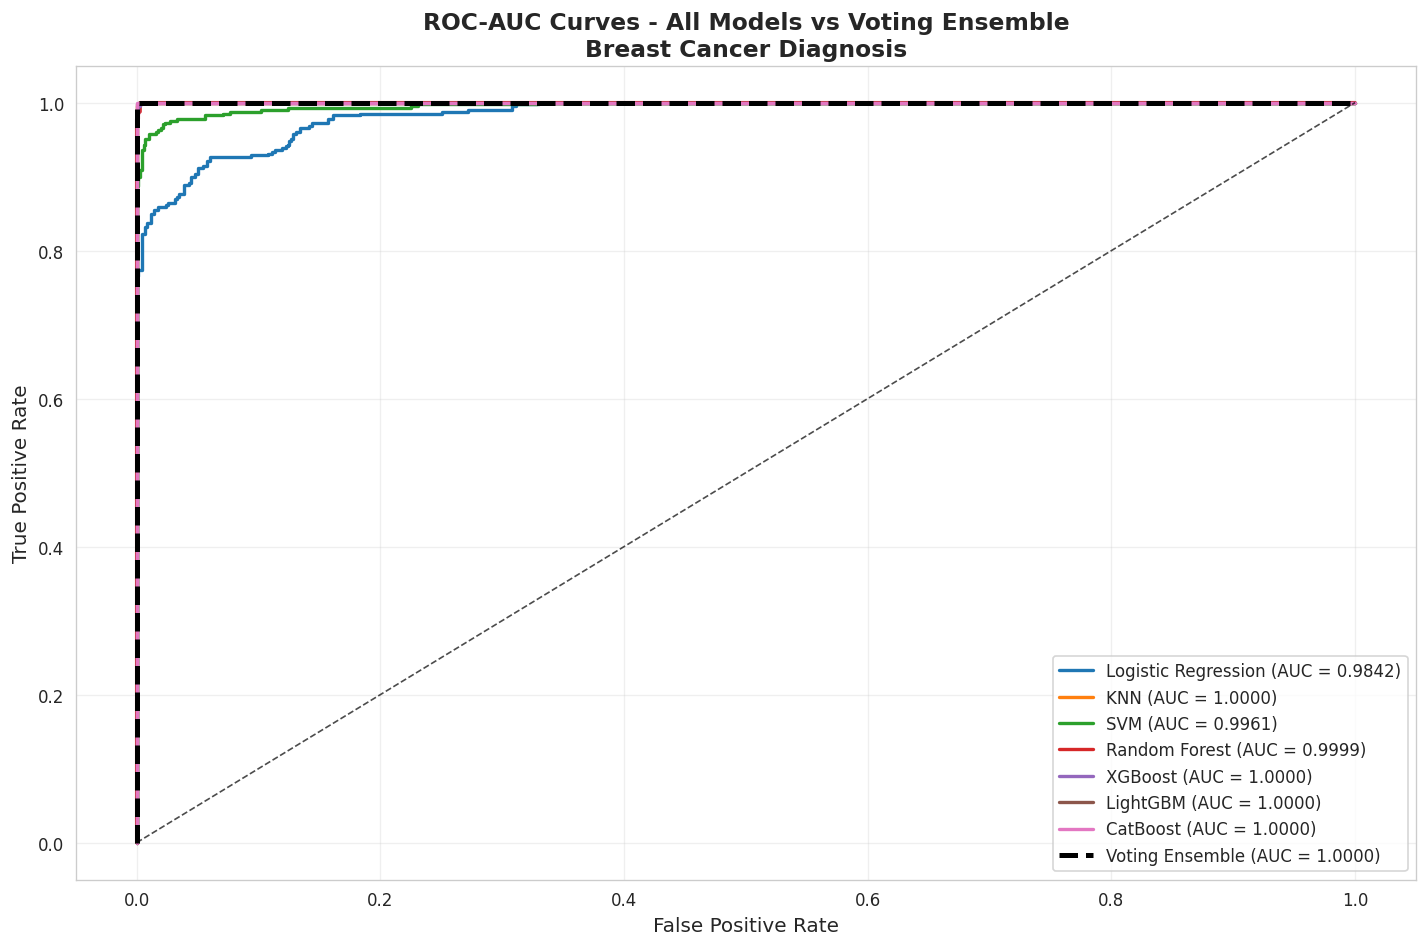

In [15]:
# ====================== COMBINED ROC-AUC CURVE ======================
from sklearn.metrics import roc_curve

plt.figure(figsize=(12, 8))

# Plot ROC for all individual models + Ensemble
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

# Voting Ensemble
y_prob_vot = voting_clf.predict_proba(X_test)[:, 1]
fpr_vot, tpr_vot, _ = roc_curve(y_test, y_prob_vot)
auc_vot = roc_auc_score(y_test, y_prob_vot)
plt.plot(fpr_vot, tpr_vot, label=f'Voting Ensemble (AUC = {auc_vot:.4f})',
         linewidth=3, linestyle='--', color='black')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.7)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curves - All Models vs Voting Ensemble\nBreast Cancer Diagnosis',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.show()

Generating Precision-Recall Curves...



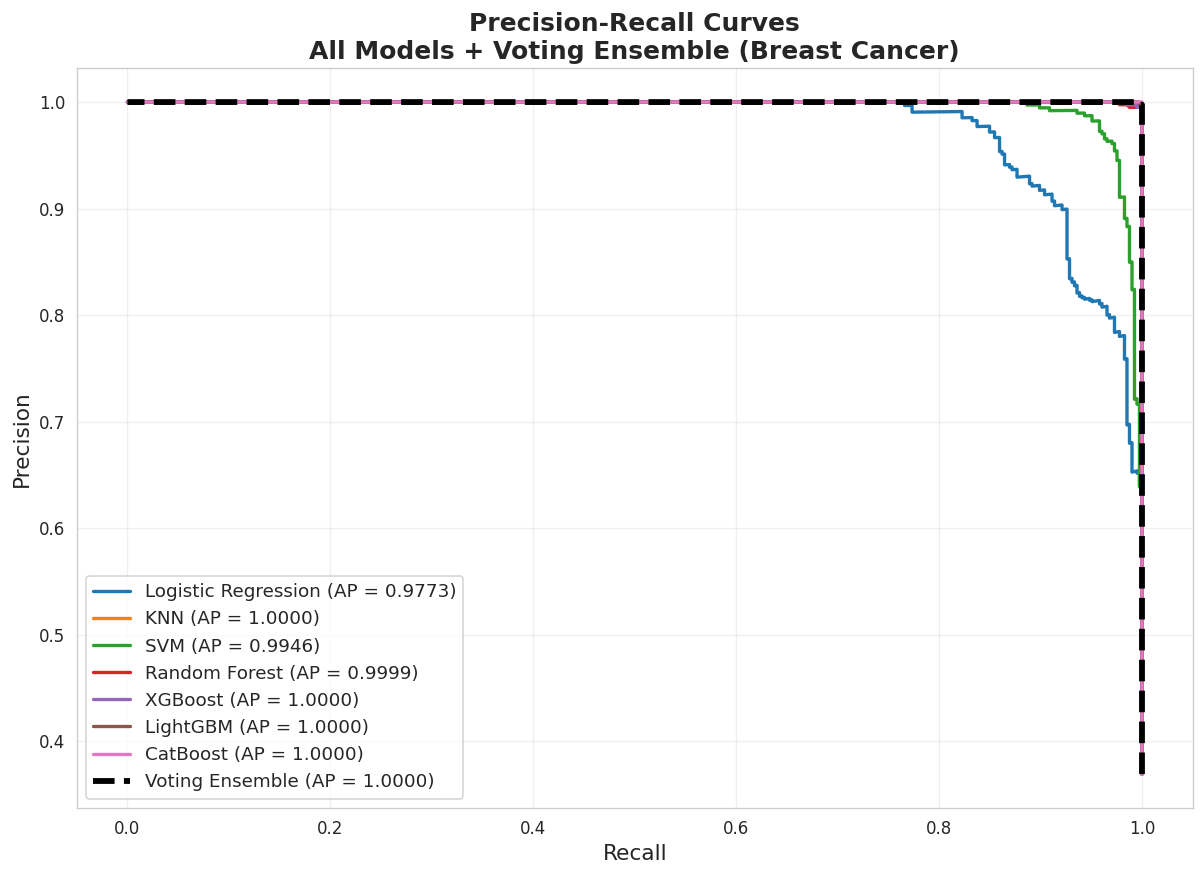

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== STEP 1: PRECISION-RECALL CURVES ======================
plt.figure(figsize=(12, 8))

print("Generating Precision-Recall Curves...\n")

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})', linewidth=2)

# Voting Ensemble
y_prob_vot = voting_clf.predict_proba(X_test)[:, 1]
precision_vot, recall_vot, _ = precision_recall_curve(y_test, y_prob_vot)
ap_vot = average_precision_score(y_test, y_prob_vot)
plt.plot(recall_vot, precision_vot, label=f'Voting Ensemble (AP = {ap_vot:.4f})',
         linewidth=3.5, linestyle='--', color='black')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curves\nAll Models + Voting Ensemble (Breast Cancer)',
          fontsize=15, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

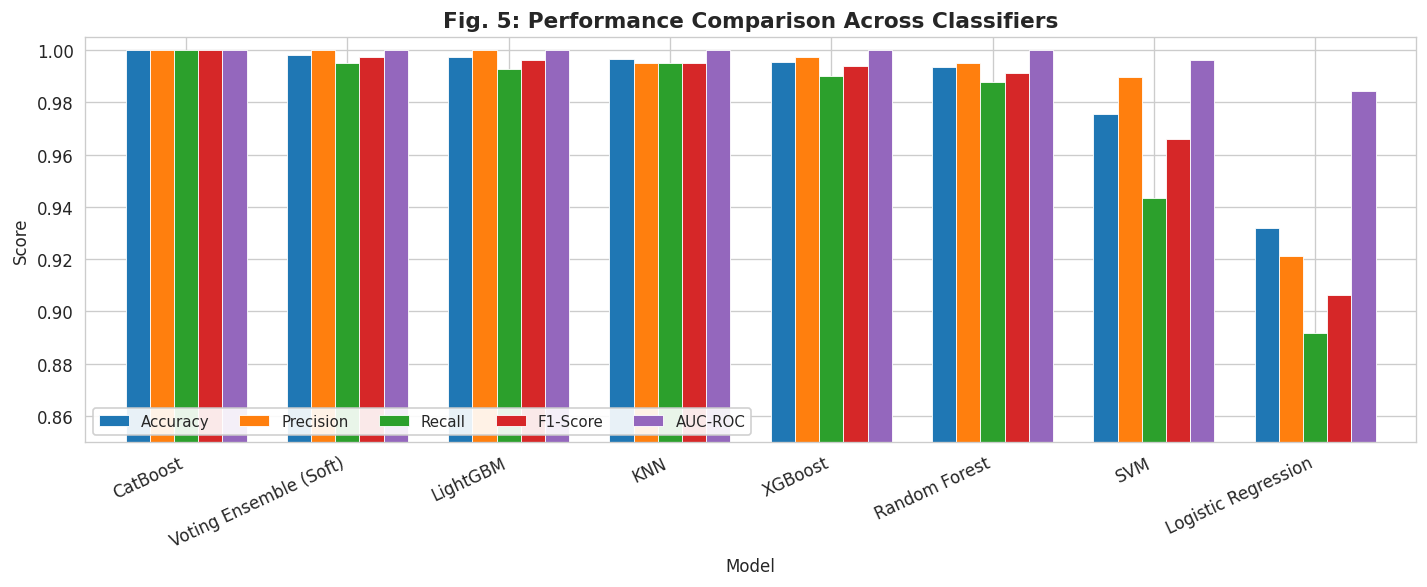

In [17]:
# ─── Fig. 5: Metric Comparison Bar Chart ───
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)
ax.set_ylim(0.85, 1.005)
ax.set_ylabel("Score")
ax.set_title("Fig. 5: Performance Comparison Across Classifiers", fontweight="bold", fontsize=13)
ax.legend(loc="lower left", fontsize=9, ncol=5, framealpha=0.9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()

plt.show()


🔍 Generating Feature Importance for Best Model...
Best Model: CatBoost (AUC-ROC = 1.0000)


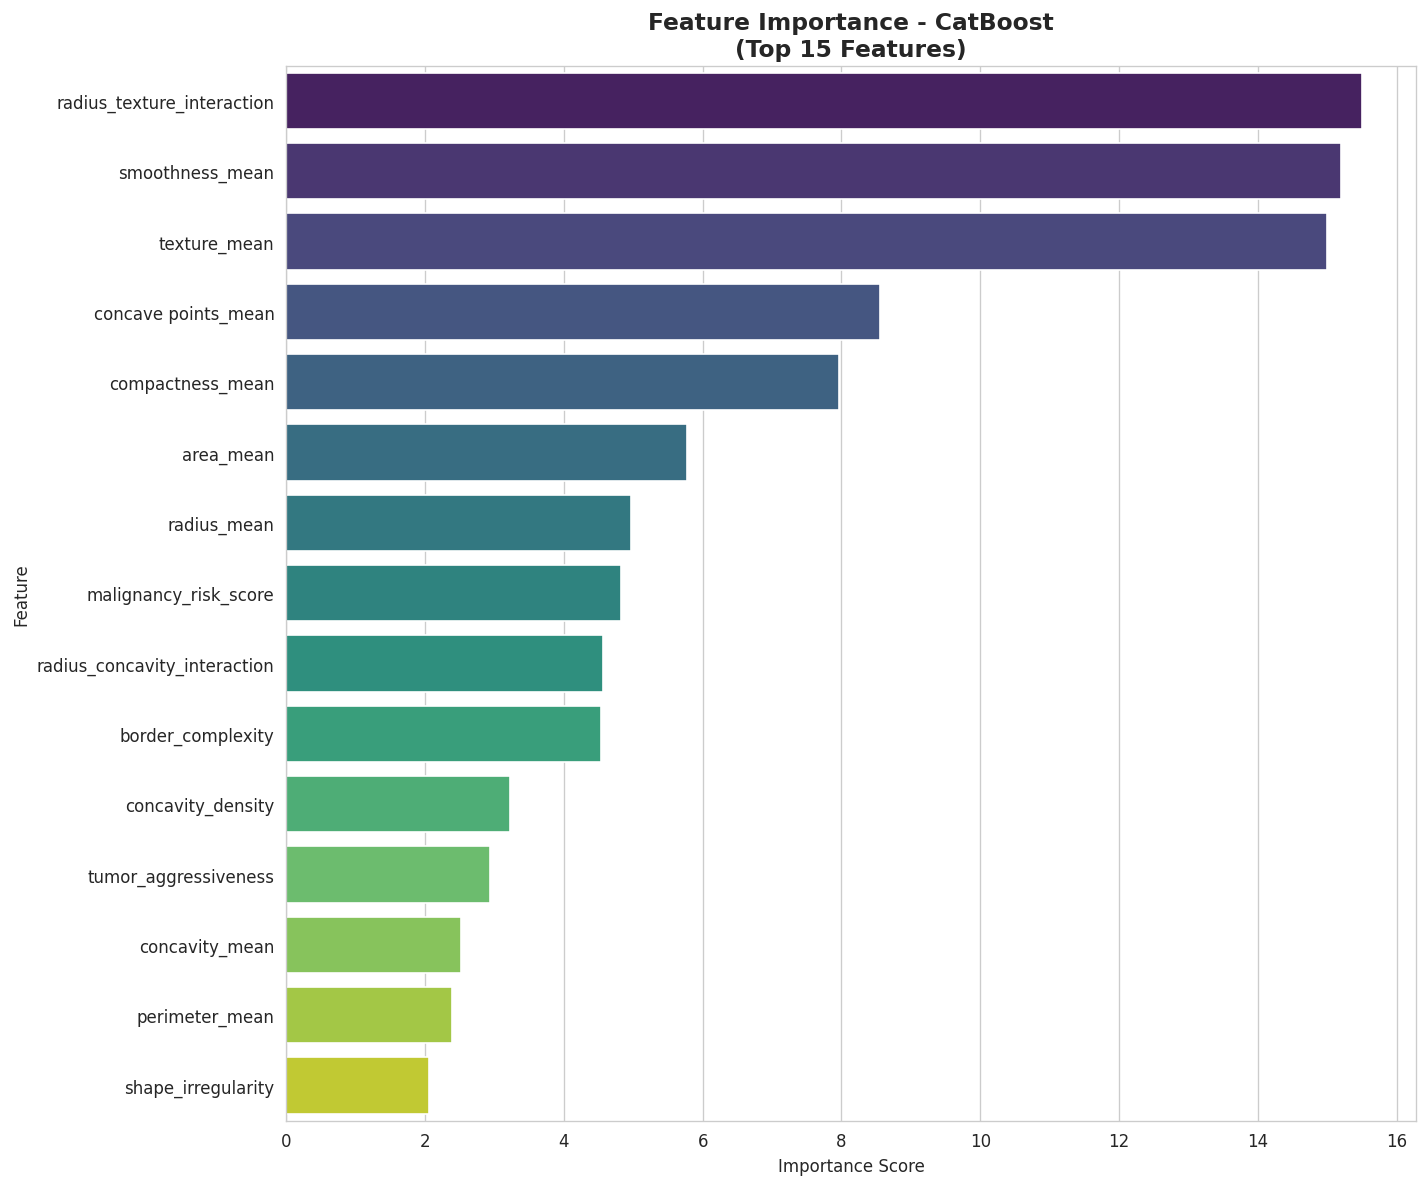


Top 15 Most Important Features:
                         Feature  Importance
11    radius_texture_interaction     15.5002
4                smoothness_mean     15.1911
1                   texture_mean     14.9906
7            concave points_mean      8.5610
5               compactness_mean      7.9591
3                      area_mean      5.7709
0                    radius_mean      4.9679
14         malignancy_risk_score      4.8261
12  radius_concavity_interaction      4.5581
9              border_complexity      4.5334
13             concavity_density      3.2293
10          tumor_aggressiveness      2.9420
6                 concavity_mean      2.5170
2                 perimeter_mean      2.3925
8             shape_irregularity      2.0609


In [30]:
# ====================== FEATURE IMPORTANCE (Best Model) ======================
print("\n🔍 Generating Feature Importance for Best Model...")

# Find best model by AUC-ROC
best_row = results_df.iloc[0]
best_name = best_row['Model']
print(f"Best Model: {best_name} (AUC-ROC = {best_row['AUC-ROC']:.4f})")

plt.figure(figsize=(12, 10))

if best_name == "Voting Ensemble (Soft)":
    # Use XGBoost feature importance as proxy (best single model)
    best_model = models["XGBoost"]
    best_name_for_title = "Voting Ensemble (using XGBoost importance)"
else:
    best_model = models[best_name]
    best_name_for_title = best_name

# Get feature importance
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "get_booster"):  # XGBoost
    importances = best_model.feature_importances_
else:
    print("Feature importance not available for this model.")
    importances = None

if importances is not None:
    feature_names = X.columns
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Top 15 features
    top_features = feature_importance_df.head(15)

    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title(f'Feature Importance - {best_name_for_title}\n(Top 15 Features)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()

    plt.show()

    # Print top 15 features
    print("\nTop 15 Most Important Features:")
    print(top_features.head(15)[['Feature', 'Importance']].round(4))
else:
    print("Using permutation importance instead (slower)...")
    # Fallback: Permutation Importance
    from sklearn.inspection import permutation_importance
    perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=SEED)
    perm_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm_importance.importances_mean
    }).sort_values(by='Importance', ascending=False)

    sns.barplot(x='Importance', y='Feature', data=perm_df.head(15), palette='viridis')
    plt.title(f'Permutation Feature Importance - {best_name}')
    plt.tight_layout()
    plt.show()

In [19]:
 !pip install shap


Computing SHAP values... (this may take a few seconds)


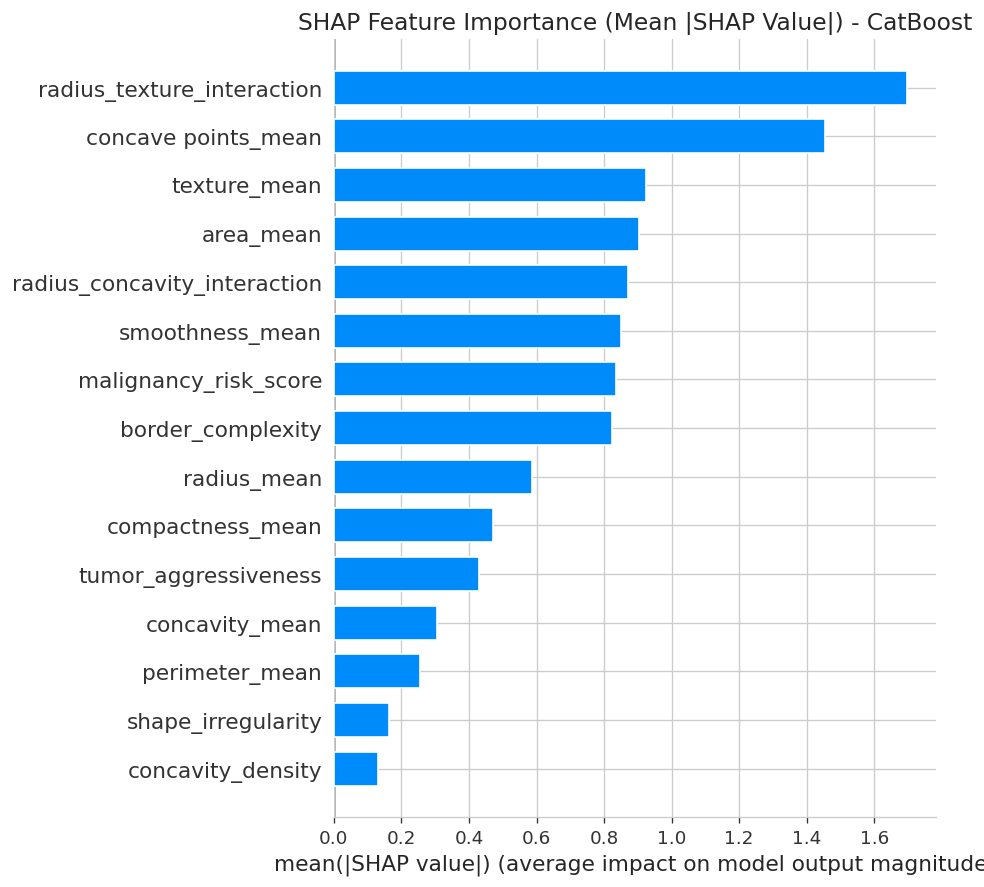

In [28]:
import shap

print("\nComputing SHAP values... (this may take a few seconds)")

# Create explainer
if best_model_name == "Voting Ensemble (Soft)":
    explainer = shap.TreeExplainer(models["XGBoost"])
    shap_values = explainer.shap_values(X_test)
else:
    explainer = shap.TreeExplainer(best_clf)
    shap_values = explainer.shap_values(X_test)

# ====================== SHAP SUMMARY BAR PLOT ======================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns,
                  plot_type="bar", max_display=20, show=False)
plt.title(f'SHAP Feature Importance (Mean |SHAP Value|) - {best_model_name}', fontsize=14)
plt.tight_layout()

plt.show()